# cu_inj reference 

In [1]:
%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


In [33]:
from impact import Impact
from distgen import Generator
import os


gfile = os.path.expandvars('$LCLS_LATTICE/distgen/models/cu_inj/v0/distgen.yaml')
#ifile = os.path.expandvars('$LCLS_LATTICE/impact/models/cu_inj/v0/ImpactT.yaml')
ifile = os.path.expandvars('$LCLS_LATTICE/impact/models/cu_inj/v0/ImpactT.in')

In [14]:
G = Generator(gfile)
G['n_particle'] = 100000
G.run()
P0 = G.particles

In [43]:
#I = Impact.from_yaml(ifile)
#I.initial_particles=P0
I = Impact(ifile)

# Change some things
#I.header['Np'] = 100000
I.header['Nx'] = 64
I.header['Ny'] = 64
I.header['Nz'] = 64
I.header['Dt'] = 5e-13

# Practical timestep
#I['change_timestep_1:dt'] = 4e-12

#I['L0AF_phase:dtheta0_deg'] = -10

#I.ele['QE10425']['zedge'] = 8

#I['QA10361:b1_gradient'] = 1
#I['QA10371:b1_gradient'] = -1
#I['QE10425:b1_gradient'] = 1
#I['QE10441:b1_gradient'] = -1
#I['QE10511:b1_gradient'] = 1
#I['QE10525:b1_gradient'] = -1

# Turn Space Charge off. Both these syntax work
#I.header['Bcurr'] = 0 
#I['header:Bcurr'] = 0 

# Other switches
I.timeout = None

# Switches for MPI
I.use_mpi=True
I.header['Nprow'] = 1
I.header['Npcol'] = 4

I.verbose=True

I.stop = 16.5

# Show repr
#I.command = os.environ['IMPACTT_BIN']
#I.command_mpi = os.environ['IMPACTT_MPI_BIN']

Removed element: stop_1
Set stop to s = 16.5


In [44]:
I.run()

Running Impact-T in /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmpl5nxkzc8
mpirun -n 4 /Users/chrisonian/Code/miniconda3/envs/devel/bin/ImpactTexe-mpi
 !-----------------------------------------------------------
 ! IMPACT-T Parallel Beam Dynamics Tracking Code: 2.1 beta version
 ! Copyright of The Regents of the University of California
 !-----------------------------------------------------------
 nblem:           60          60
 pass setting up lattice...
 check randomness:            0  0.79479214134216858     
 check randomness:            2  0.68444898109486740     
 check randomness:            1  0.65948074101936072     
 check randomness:            3  0.79369999429767613     
 avgpts, jlow, and jhigh:         2500           1        2500
 avgpts, jlow, and jhigh:         2500        5001        7500
 avgpts, jlow, and jhigh:         2500        7501       10000
 avgpts, jlow, and jhigh:         2500        2501        5000
 time:    12846.673092000001, elapsed: 12846.98

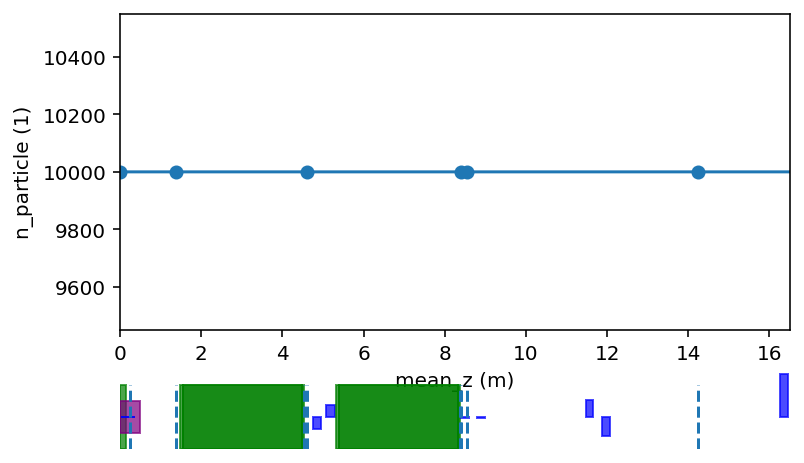

In [45]:
I.plot('n_particle')

In [46]:
I.particles['final_particles']['norm_emit_x']

1.132428317830425e-06

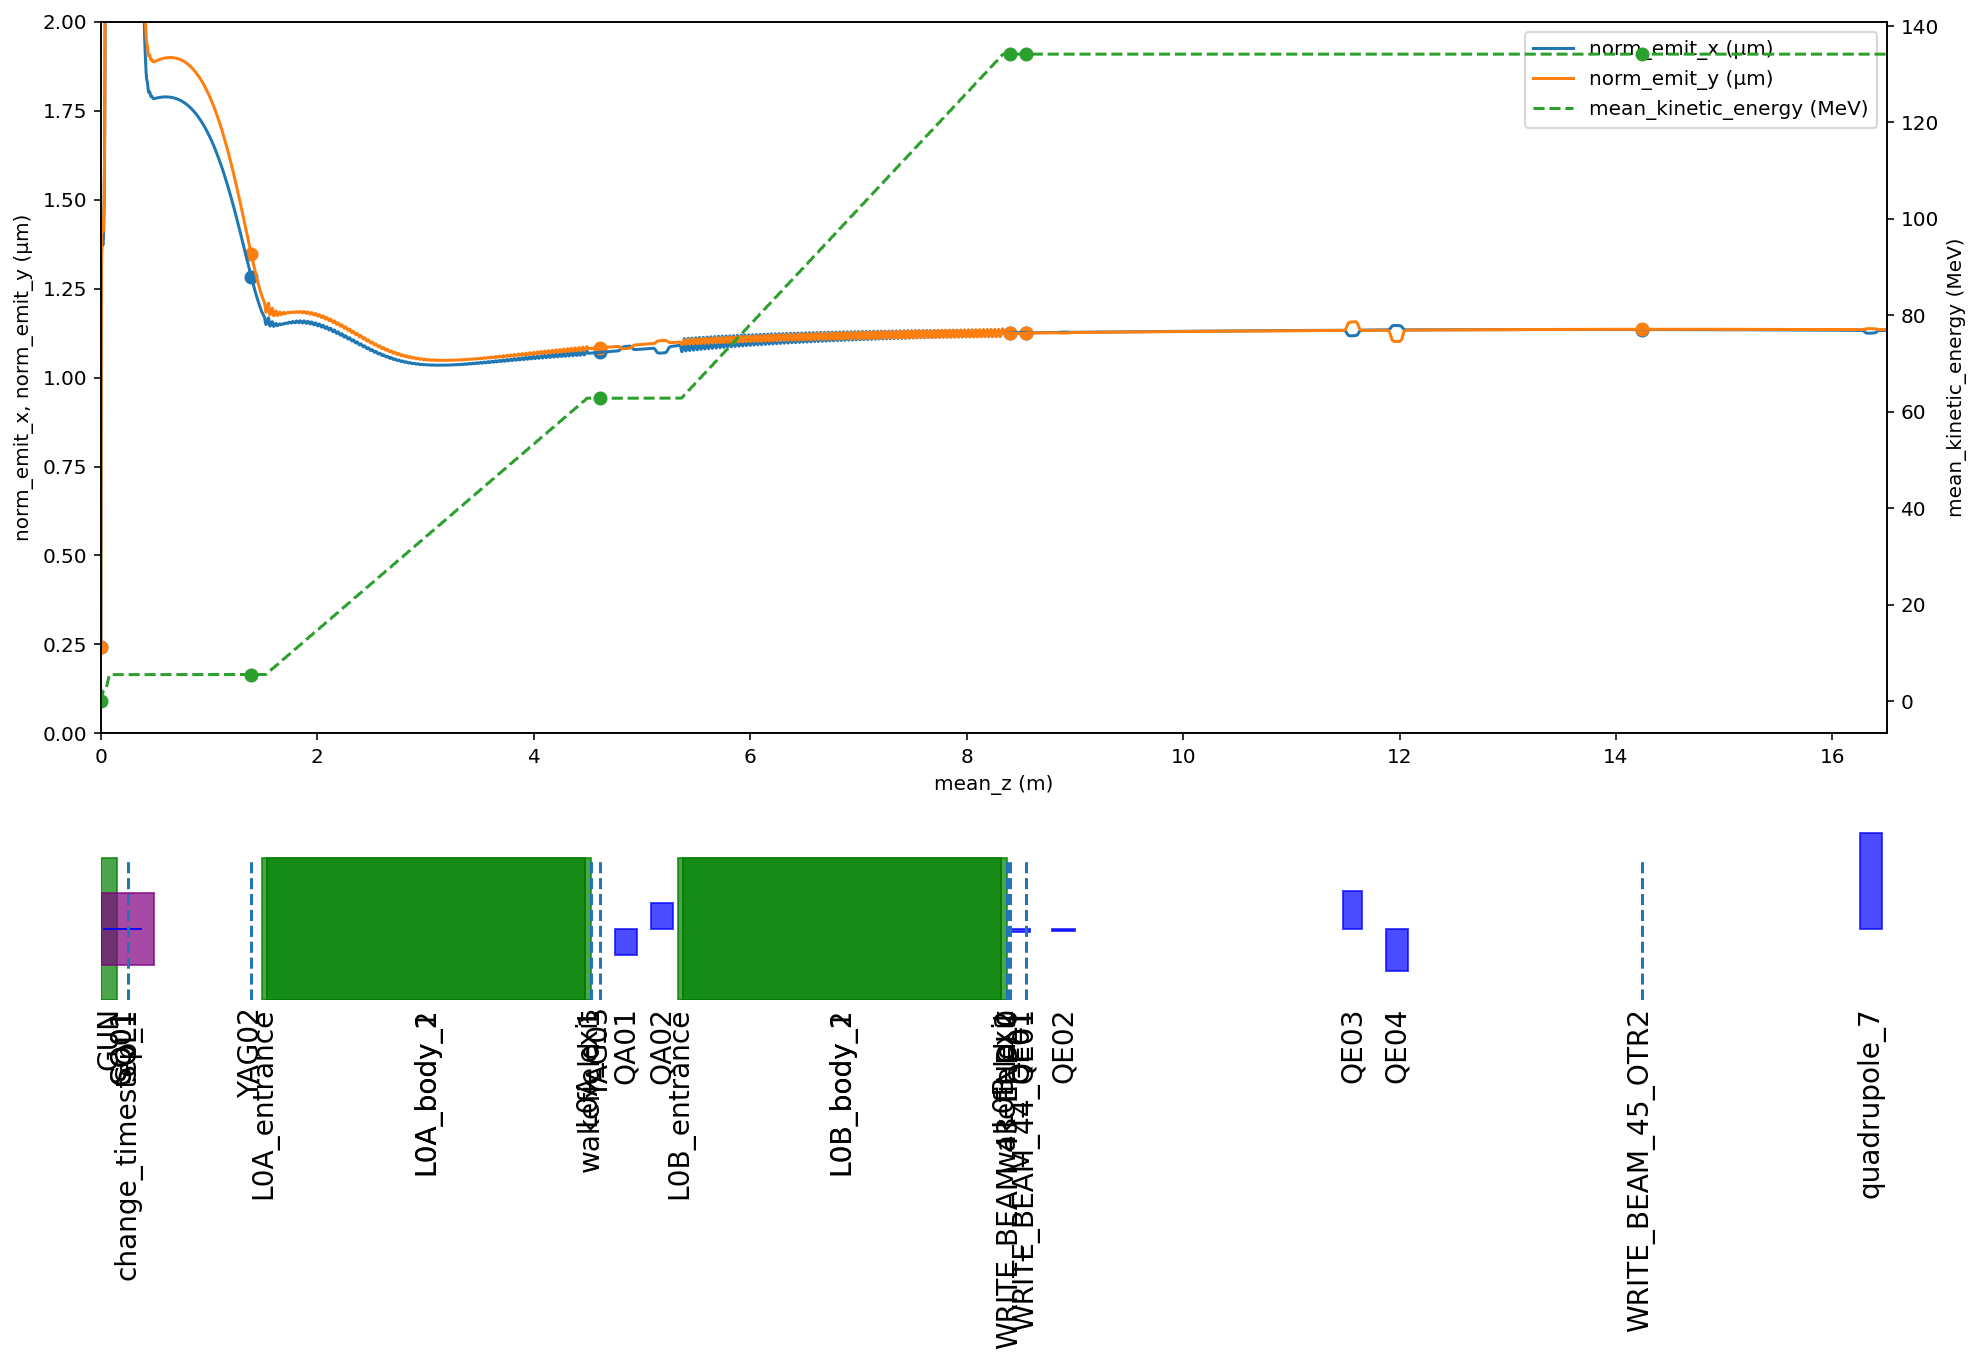

In [47]:
I.plot(['norm_emit_x', 'norm_emit_y'], y2=['mean_kinetic_energy'], figsize=(16,9),
       ylim=(0, 2e-6), include_labels=True)

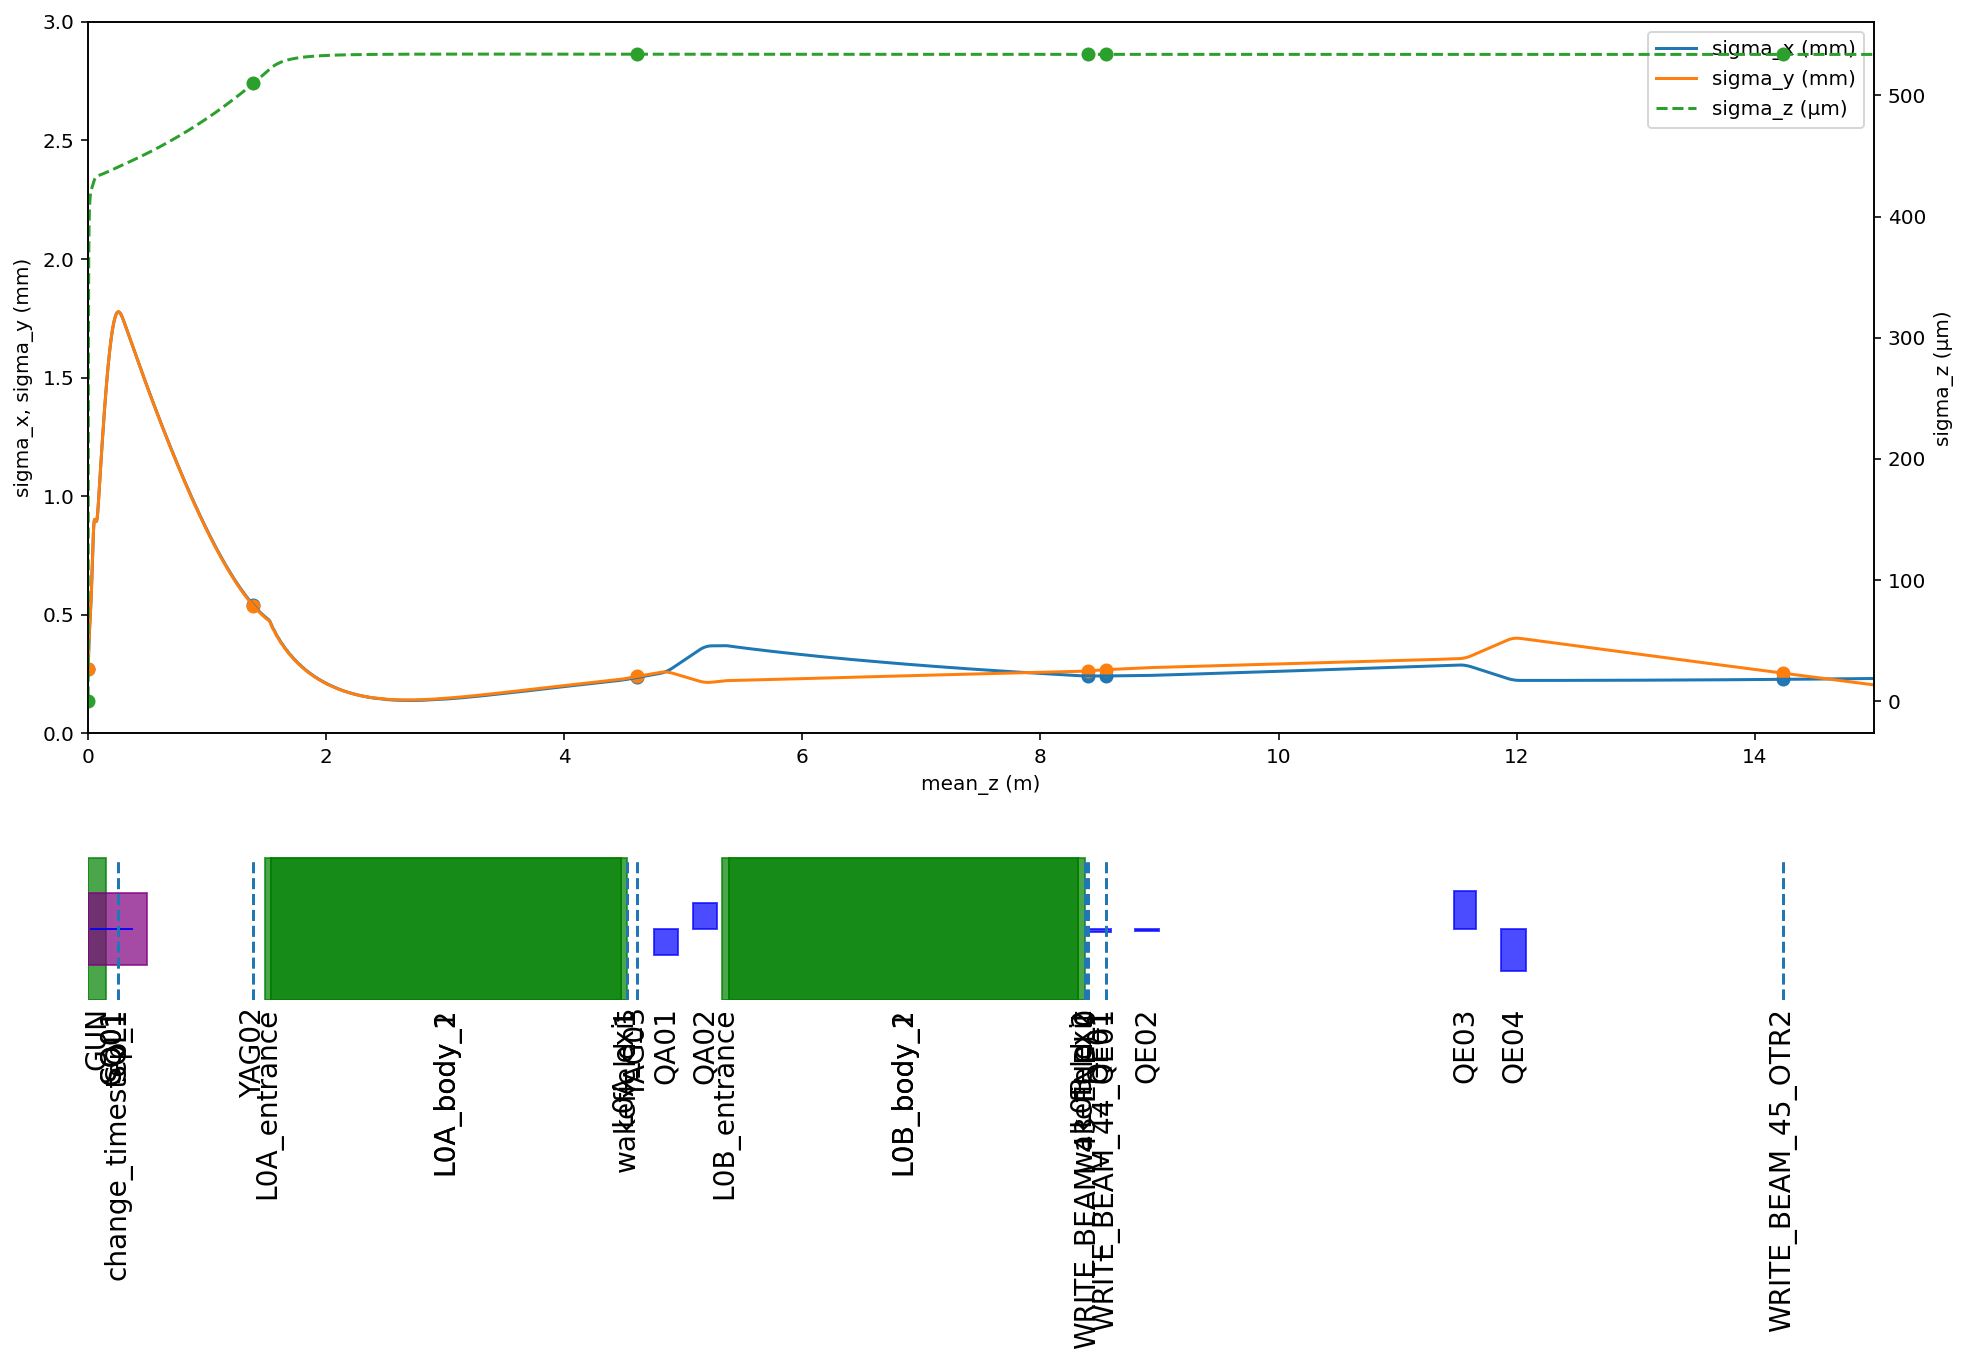

In [39]:
I.plot(['sigma_x', 'sigma_y'], y2='sigma_z', figsize=(16,9), ylim=(0,3e-3), xlim=(0,15), include_labels=True)

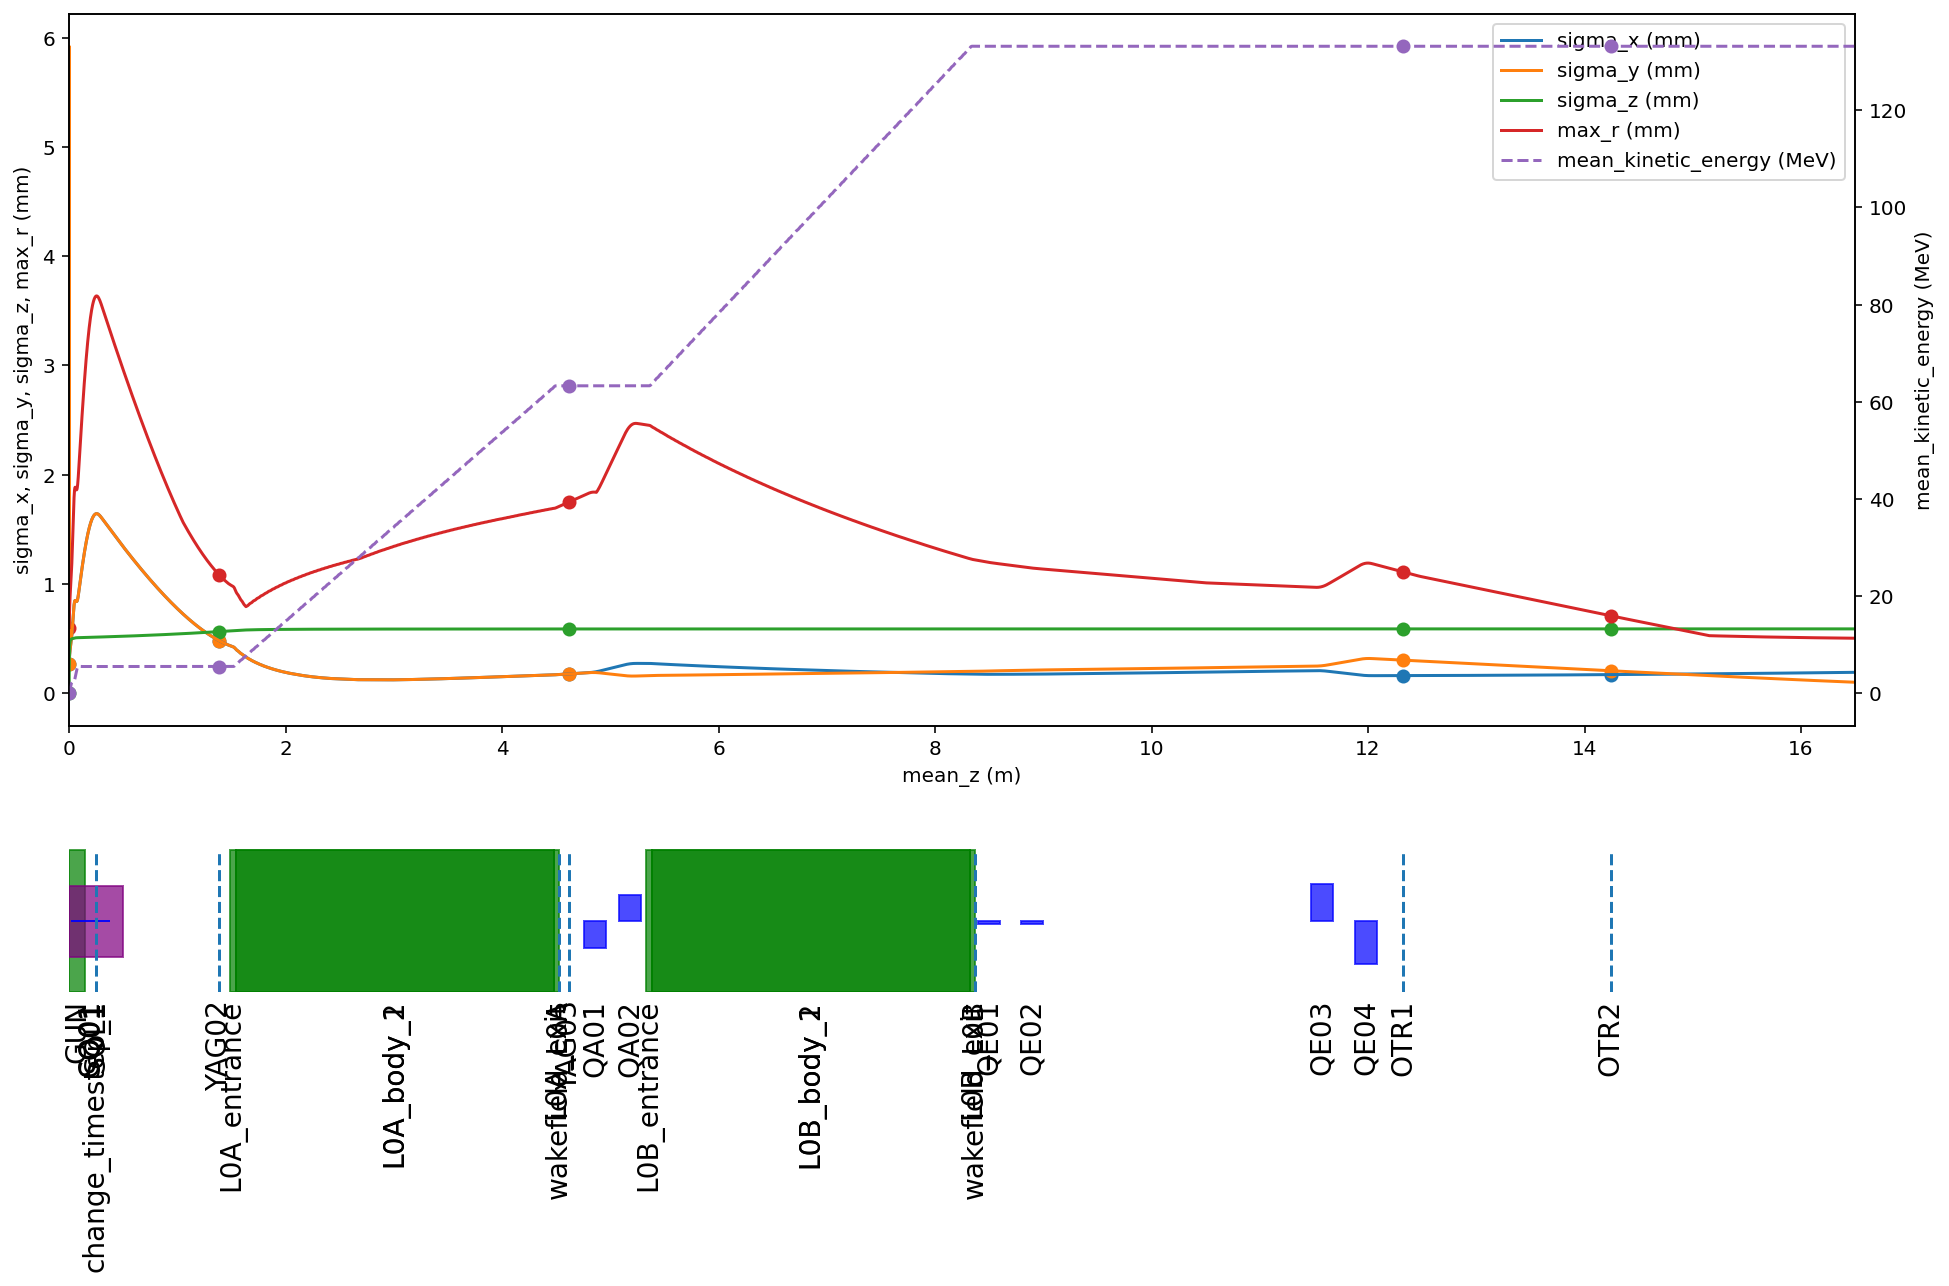

In [21]:
I.plot(['sigma_x', 'sigma_y', 'sigma_z', 'max_r'], y2=['mean_kinetic_energy'],
       figsize=(16,9), include_labels=True)

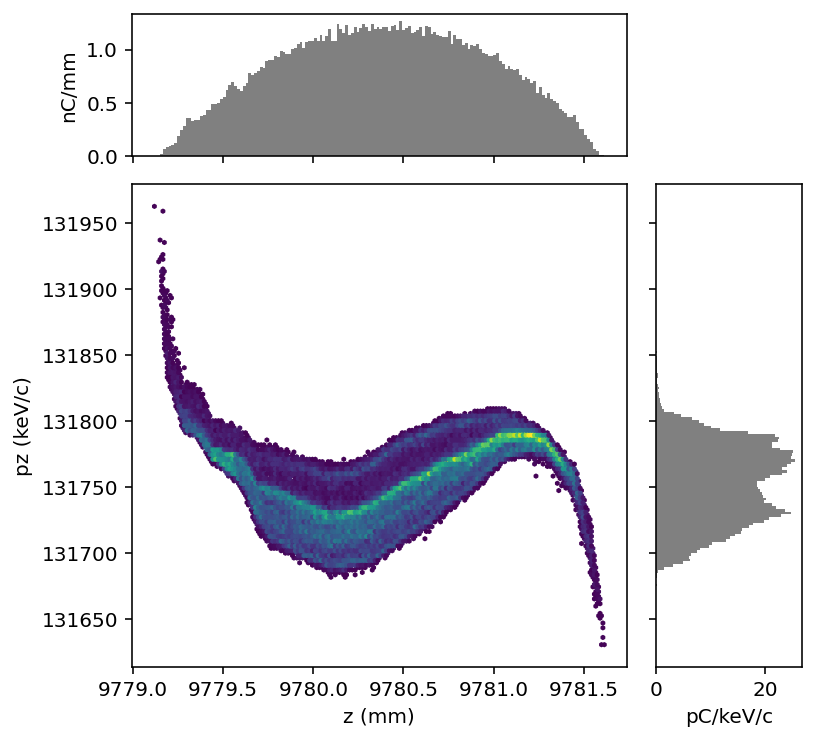

In [20]:
I.particles['PR10471'].plot('z', 'pz', figsize=(6,6))

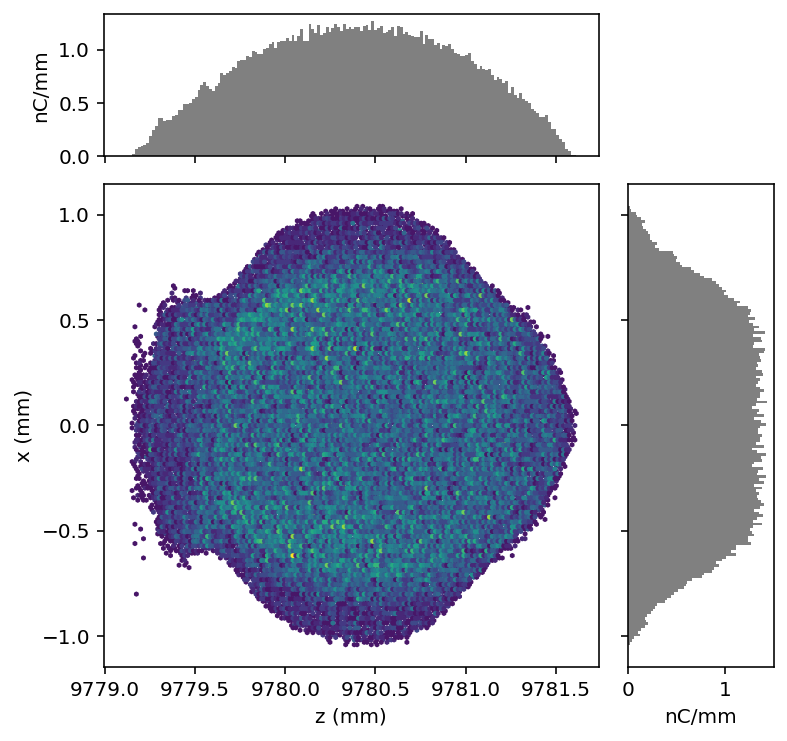

In [22]:
I.particles['PR10471'].plot('z', 'x', figsize=(6,6))